In [6]:
import os
import pathlib
import matplotlib.pyplot as plt
import json

node_logs = []

nodes = 10

for i in range(nodes):
    node = pathlib.Path(f"./results/node_{i}").resolve()
    if node.exists():
        logs = node.glob("*.txt")
        latest_log = None
        for log in logs:
            if latest_log == None:
                latest_log = log
                continue
            current_timestamp = log.name.replace("log_","").replace(".txt","")
            lastest_timestamp = latest_log.name.replace("log_","").replace(".txt","")
            if float(current_timestamp)>float(lastest_timestamp):
                latest_log = log
        if latest_log:
            node_logs.append(json.loads(latest_log.read_text()))

print(node_logs)


[[[[0.48899896879021715, 0.2918947268792284, 0.22588410991721036, 0.19975828870040616, 0.1862668316902184, 0.18618889558848326, 0.17824115801027152, 0.17276695894637728, 0.16879235725940728, 0.16511438765782652, 0.1719312825035758, 0.16702991003185752, 0.16362403523994656, 0.1585761006103783, 0.15468962914575407, 0.16753122625433334, 0.16124537132862138, 0.15572975070132472, 0.15078464653191528, 0.145579268262396, 0.16491047819940055, 0.15709458739776921, 0.15008405441554581, 0.14445881839326727, 0.1382586827607659, 0.16169242415486312, 0.15178071886179892, 0.1456526874345008, 0.13939999670880596, 0.13274178476777018, 0.15988691514585077, 0.1485967043090642, 0.14116679234960214, 0.1341314501454675, 0.12759404400802724, 0.15754842973215794, 0.14447323145057128, 0.1364874595670196, 0.13063795295188096, 0.12347713361183803, 0.1557492363622518, 0.14175349146854588, 0.132646094311059, 0.12633271754636027, 0.11997743514252872, 0.15286709916422037, 0.13771974131828402, 0.12953530927377988, 0.

In [7]:

import numpy as np

numpy_logs = np.array(node_logs)
average_logs = np.mean(numpy_logs,axis=0).tolist()

avg_train_loss = average_logs[0][0]
avg_train_acc = average_logs[0][1]
avg_val_loss = average_logs[1][0]
avg_val_acc = average_logs[1][1]

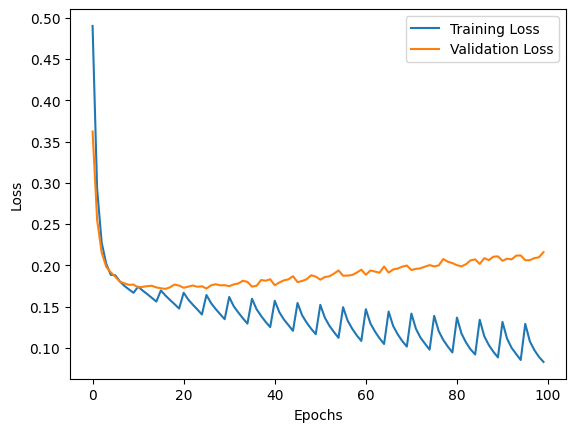

Epochs : 100


In [8]:
plt.plot(avg_train_loss,label="Training Loss")
plt.plot(avg_val_loss,label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print(f"Epochs : {len(avg_train_acc)}")

In [9]:
columns = ('Training Accuracy', 'Validation Accuracy')
rows = [1,5,10, 25, 50, 75, 100]

train_accs = [f"{round(avg_train_acc[rows[i]-1]*100,3)}%" for i in range(len(rows))]
val_accs = [f"{round(avg_val_acc[rows[i]-1]*100,3)}%" for i in range(len(rows))]
import pandas as pd

pd.DataFrame(np.transpose([train_accs,val_accs]),columns=columns,index=rows)

,Training Accuracy,Validation Accuracy
1,81.813%,93.904%
5,94.86%,94.919%
10,94.902%,94.904%
25,95.335%,94.746%
50,95.993%,94.371%
75,96.603%,94.245%
100,97.114%,94.009%


In [10]:
val_max = max(avg_val_acc)
print(f"Best Validation Accuracy : {round(val_max*100,3)}%")

Best Validation Accuracy : 94.923%
